In [10]:
from representations import load_model, load_examples, extract_generated, check_correctness
from frechet_analysis import (
    discrete_frechet_distance,
    arc_length,
    make_reference_line,
    wandering_ratio,
    analyze_model,
    plot_wandering_by_layer,
    plot_correct_vs_incorrect,
    plot_scatter,
)

In [11]:
MODELS = {
    "NTP": "/home/jay/repos/llm-jepa/output-exp1-regular",
    "STP": "/home/jay/repos/llm-jepa/output-exp1-stp",
}
DATA_FILE = "/home/jay/repos/llm-jepa/datasets/synth_test.jsonl"
BASE_MODEL = "meta-llama/Llama-3.2-1B-Instruct"
N_EXAMPLES = 300
MAX_NEW_TOKENS = 128

In [12]:
examples = load_examples(DATA_FILE, BASE_MODEL, n=N_EXAMPLES)
print(f"Loaded {len(examples)} examples")

Loaded 300 examples


In [13]:
all_results = {}
for label, model_path in MODELS.items():
    all_results[label] = analyze_model(
        model_path, BASE_MODEL, examples, DATA_FILE, MAX_NEW_TOKENS,
    )


Loading /home/jay/repos/llm-jepa/output-exp1-regular...


Loading weights:   0%|          | 0/146 [00:00<?, ?it/s]

Extracting: 100%|██████████| 300/300 [09:22<00:00,  1.87s/it]



Loading /home/jay/repos/llm-jepa/output-exp1-stp...


Loading weights:   0%|          | 0/146 [00:00<?, ?it/s]

Extracting: 100%|██████████| 300/300 [06:57<00:00,  1.39s/it]


In [14]:
import numpy as np

for label, results in all_results.items():
    correct = sum(1 for r in results if r["correct"])
    total = len(results)
    mean_wr = np.mean([r["wandering_ratios"][-1] for r in results])
    print(f"{label}: {correct}/{total} correct, mean wandering ratio (last layer): {mean_wr:.4f}")

NTP: 81/300 correct, mean wandering ratio (last layer): 0.0796
STP: 202/300 correct, mean wandering ratio (last layer): 0.0891


In [15]:
  for label, results in all_results.items():
      print(f"\n--- {label} ---")
      for r in results[:3]:
          print(f"  gen: {repr(r['generated_text'][:80])}")



--- NTP ---
  gen: '~((dog.*[0-9].*){3,})'
  gen: '.*((.*)([AEIOUaeiou]))*.*.*.*.*.*.*.*.*.*.*.*.*.*.*.*.*.*.*.*.*.*.*.*.*.*.*.*.*.'
  gen: '(([0-9])|(.)).*([AEIOUaeiou]).*'

--- STP ---
  gen: '~((dog.*[0-9].*){3,})'
  gen: '(.*)(.*){([AEIOUaeiou])*}'
  gen: '(([0-9])|(.)).*([AEIOUaeiou]).*'


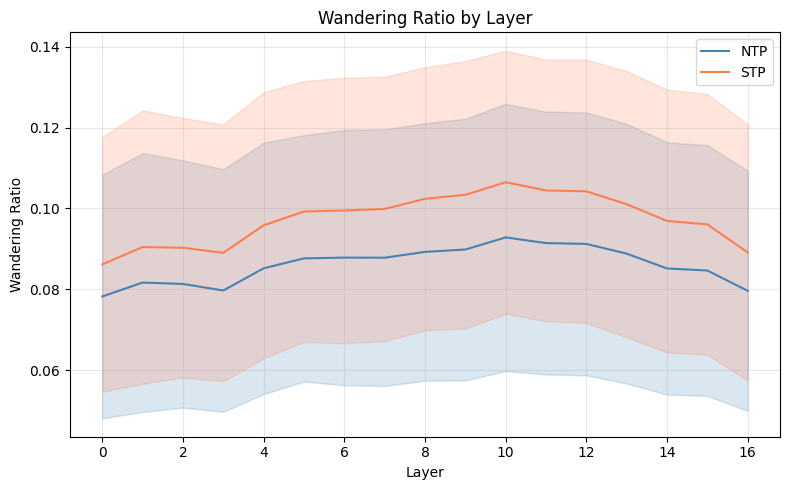

In [16]:
labels = list(all_results.keys())
results_list = list(all_results.values())

plot_wandering_by_layer(results_list, labels)

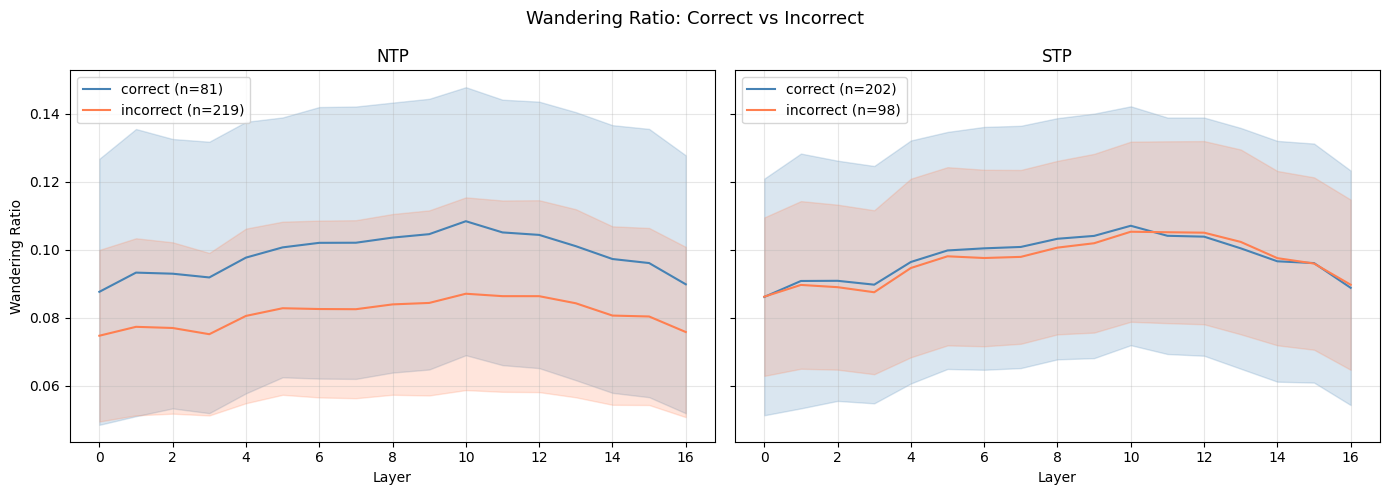

In [17]:
plot_correct_vs_incorrect(results_list, labels)

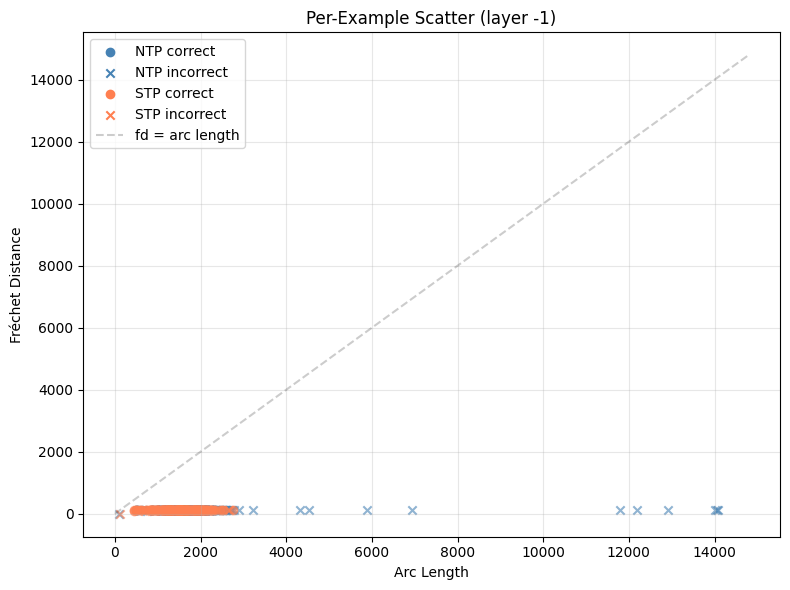

In [18]:
plot_scatter(results_list, labels)

Finding: the trajectories according to this are both pretty straight already.